[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](
https://colab.research.google.com/github/KalininGroup/camm_hackathon/blob/k4my4r/docs/day_7_13022026/07a_CAMM_ExplainableML_Spectrum.ipynb)


# Explainable XRD Regression with Attention Pooling (Experimental DyErGdHo)

Notebook: Aditya Raghavan
Idea: Sergei Kalinin, Utkarsh Pratiush
Sample and Data: Page and Rack groups

## 0. Setup (imports, device, reproducibility)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

import os, glob, re, random
import pandas as pd

from scipy.signal import savgol_filter
from scipy.spatial import cKDTree
from scipy.interpolate import LinearNDInterpolator, NearestNDInterpolator
from sklearn.model_selection import train_test_split

# Repro
np.random.seed(42)
torch.manual_seed(42)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

def set_seed(seed=42):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

set_seed(42)

os.makedirs("ablation_plots_1", exist_ok=True)

DEVICE: cpu


## 1. Data download and unzip

In [ ]:
# Data ZIP
!gdown --fuzzy https://drive.google.com/file/d/1Ez232Z0HVdkKrSdqZMUe96NpAl_Z9guq/view?usp=sharing
!unzip -o CAMM-DyErGdHo_Data.zip

# Additional CSVs
!gdown --fuzzy https://drive.google.com/file/d/1WrZoxyW1T30KQS-BP8kaJIZWloNdRyN5/view?usp=sharing
!gdown --fuzzy https://drive.google.com/file/d/18RLkCDAR0FsG9D8jv3fUMHWDOxThpvY7/view?usp=sharing
!gdown --fuzzy https://drive.google.com/file/d/1DnLB07J7JXoPSNUU0Hcz-v7HH7IrZNdh/view?usp=drive_link

Downloading...
From (original): https://drive.google.com/uc?id=1Ez232Z0HVdkKrSdqZMUe96NpAl_Z9guq
From (redirected): https://drive.google.com/uc?id=1Ez232Z0HVdkKrSdqZMUe96NpAl_Z9guq&confirm=t&uuid=84d3b868-1675-458d-96e2-1e2cb7c663c0
To: /content/CAMM-DyErGdHo_Data.zip
100% 104M/104M [00:01<00:00, 92.9MB/s] 
Archive:  CAMM-DyErGdHo_Data.zip
   creating: XY/
  inflating: FullMap_5x5center.xlsx  
  inflating: README.md               
  inflating: ZscoreRefined_Data.xlsx  
  inflating: amorphouswafer_DyErGdHo_xrd_Template1_spf_comparison.csv  
  inflating: XY/1fb033_-4p9999_15p0_point278.xy  
  inflating: XY/59d2ce_-29p9998_30p0_point091.xy  
  inflating: XY/819b6b_-7p5_-15p0_point680.xy  
  inflating: XY/855786_32p5001_30p0_point115.xy  
  inflating: XY/18351f_37p5002_5p0001_point428.xy  
  inflating: XY/286737_-17p5_-5p0_point543.xy  
  inflating: XY/f4d8a9_25p0001_-25p0001_point815.xy  
  inflating: XY/835a54_-7p5_-40p0_point943.xy  
  inflating: XY/0ae4c5_27p5002_2p5_point457.xy  
  in

## 2. Data prep helper functions (exact)

In [ ]:
def find_xy_folder(preferred=None, pattern="point*.xy", search_roots=(".", "/content")):
    """Return a folder path that contains files matching pattern."""
    if preferred is not None:
        preferred = os.path.expanduser(preferred)
        if os.path.isdir(preferred):
            hits = glob.glob(os.path.join(preferred, pattern))
            if len(hits) > 0:
                return preferred

    for root in search_roots:
        root = os.path.expanduser(root)
        if not os.path.isdir(root):
            continue
        hits = glob.glob(os.path.join(root, "**", pattern), recursive=True)
        if len(hits) > 0:
            return os.path.dirname(hits[0])

    raise FileNotFoundError(
        f"Could not find any '{pattern}' under roots={search_roots}. "
        "Check that the zip extracted correctly and that filenames look like 'point123.xy'."
    )

_POINT_RE = re.compile(r"(?:^|_)point(\d+)\.xy$", flags=re.IGNORECASE)

def load_xy_folder(xy_folder, pattern="*_point*.xy"):
    """Read .xy files and return dict: xy_data[point_id] = {'2theta':..., 'intensity':...}."""
    xy_data = {}
    files = sorted(glob.glob(os.path.join(xy_folder, pattern)))
    if len(files) == 0:
        raise FileNotFoundError(f"No files matching {pattern} found in folder: {xy_folder}")

    skipped = 0
    for fp in files:
        name = os.path.basename(fp)
        m = _POINT_RE.search(name)
        if not m:
            skipped += 1
            continue

        point_id = int(m.group(1))
        arr = np.loadtxt(fp)
        if arr.ndim != 2 or arr.shape[1] < 2:
            raise ValueError(f"Unexpected format in {fp}: shape={arr.shape}")

        xy_data[point_id] = {"2theta": arr[:, 0], "intensity": arr[:, 1]}

    if len(xy_data) == 0:
        raise FileNotFoundError(
            f"Found files, but none matched the expected '*_point###.xy' pattern in {xy_folder}.\n"
            f"Example file: {os.path.basename(files[0])}"
        )

    if skipped > 0:
        print(f"⚠️ Skipped {skipped} files that did not match '*_point###.xy' naming.")

    return xy_data

def safe_savgol(X, win=7, poly=3, axis=1, mode="nearest"):
    X = np.asarray(X)
    if X.dtype not in (np.float32, np.float64):
        X = X.astype(np.float32, copy=False)
    if not X.flags.c_contiguous:
        X = np.ascontiguousarray(X)
    if not np.isfinite(X).all():
        raise ValueError("NaN/Inf detected in X")
    if X.ndim != 2:
        raise ValueError(f"Expected 2D array, got shape {X.shape}")
    if win % 2 == 0 or poly >= win or X.shape[axis] < win:
        raise ValueError("Invalid (window_length, polyorder) for given axis length")
    return savgol_filter(X, window_length=win, polyorder=poly, axis=axis, mode=mode)

def scale_per_spectrum(X, q=95):
    s = np.percentile(X, q, axis=1, keepdims=True)
    s[s == 0] = 1.0
    return X / s

def plot_spectrum(two_theta, X, i=0, title="Spectrum sanity check"):
    plt.figure(figsize=(10, 4))
    plt.plot(two_theta, X[i])
    plt.xlabel("2θ (deg)")
    plt.ylabel("Intensity (processed)")
    plt.title(f"{title} — index {i}")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def build_spectra_dataset(
    xy_folder,
    metadata_csv,
    point_col="point",
    x_col="x",
    y_col="y",
    coords_mm_to_cm=True,
    bgsub=True,
    clip_bgsub=True,
    down=10,
    crop_2theta=(2.5, 10.0),
    smooth=(7, 3),
    per_spectrum_scale_q=95,
    mask_fn=None,
):
    xy_data = load_xy_folder(xy_folder)

    df = pd.read_csv(metadata_csv).copy()
    if point_col not in df.columns:
        raise ValueError(f"'{point_col}' not found in metadata CSV columns: {list(df.columns)}")

    df[point_col] = df[point_col].astype(int)

    if coords_mm_to_cm:
        if x_col not in df.columns or y_col not in df.columns:
            raise ValueError(f"Expected coordinate columns '{x_col}','{y_col}' not found in metadata CSV.")
        df[x_col] = df[x_col] / 10.0
        df[y_col] = df[y_col] / 10.0

    valid_df = df[df[point_col].isin(xy_data.keys())].copy()
    valid_df = valid_df.sort_values(by=point_col).reset_index(drop=True)

    if len(valid_df) == 0:
        raise ValueError("No overlapping points between metadata CSV and XY spectra.")

    points = valid_df[point_col].to_numpy()
    two_theta = xy_data[int(points[0])]["2theta"].copy()

    X = np.stack([xy_data[int(pid)]["intensity"] for pid in points], axis=0).astype(np.float32)

    X_min, X_max = float(X.min()), float(X.max())
    if X_max == X_min:
        raise ValueError("Spectra are constant; cannot normalize.")
    X = (X - X_min) / (X_max - X_min)

    if bgsub:
        X = X - X.mean(axis=1, keepdims=True)
        if clip_bgsub:
            X = np.clip(X, 0, None)

    if down is not None and down > 1:
        X = X[:, ::down]
        two_theta = two_theta[::down]

    if crop_2theta is not None:
        lo, hi = crop_2theta
        mask = (two_theta >= lo) & (two_theta <= hi)
        X = X[:, mask]
        two_theta = two_theta[mask]

    if smooth is not None:
        win, poly = smooth
        X = safe_savgol(X, win=win, poly=poly, axis=1, mode="nearest")

    if per_spectrum_scale_q is not None:
        X = scale_per_spectrum(X, q=per_spectrum_scale_q)

    if mask_fn is not None:
        keep = np.asarray(mask_fn(valid_df), dtype=bool)
        if keep.shape[0] != len(valid_df):
            raise ValueError("mask_fn returned wrong length.")
        valid_df = valid_df.loc[keep].reset_index(drop=True)
        X = X[keep]

    dataset = {
        "X": np.asarray(X, dtype=np.float32),
        "two_theta": np.asarray(two_theta, dtype=np.float32),
        "df_points": valid_df,
        "xy_data": xy_data,
    }
    return dataset

def attach_target_from_file(
    dataset,
    target_file,
    target_col,
    x_col="x",
    y_col="y",
    file_is_mm=False,
    round_decimals=4,
    nn_tol_cm=0.03,
    drop_missing=True,
):
    df_t = pd.read_csv(target_file).copy()
    if target_col not in df_t.columns:
        raise ValueError(f"target_col='{target_col}' not found in {target_file}. Columns={list(df_t.columns)}")
    if x_col not in df_t.columns or y_col not in df_t.columns:
        raise ValueError(f"Expected x/y columns '{x_col}','{y_col}' not in {target_file}.")

    df_t = df_t[[x_col, y_col, target_col]].rename(columns={x_col: "x", y_col: "y", target_col: "target"})

    if file_is_mm:
        df_t["x"] = df_t["x"] / 10.0
        df_t["y"] = df_t["y"] / 10.0

    df_main = dataset["df_points"].copy()

    df_main["x_round"] = df_main["x"].round(round_decimals)
    df_main["y_round"] = df_main["y"].round(round_decimals)

    df_t["x_round"] = df_t["x"].round(round_decimals)
    df_t["y_round"] = df_t["y"].round(round_decimals)

    idx_t = df_t.set_index(["x_round", "y_round"])
    keys = list(zip(df_main["x_round"], df_main["y_round"]))
    y = idx_t.reindex(keys)["target"].to_numpy(dtype=np.float32)

    missing = np.isnan(y)
    print(f"[target join] Direct matches: {(~missing).sum()} / {len(y)}")

    if missing.any():
        tree = cKDTree(df_t[["x", "y"]].to_numpy())
        qxy = df_main.loc[missing, ["x", "y"]].to_numpy()
        dist, nn_idx = tree.query(qxy, k=1)

        nn_vals = df_t.iloc[nn_idx]["target"].to_numpy(dtype=np.float32)
        miss_rows = np.where(missing)[0]

        filled = 0
        for j, (d, val) in enumerate(zip(dist, nn_vals)):
            if np.isfinite(d) and d <= nn_tol_cm:
                y[miss_rows[j]] = val
                filled += 1

        still = int(np.isnan(y).sum())
        print(f"[target join] NN filled within {nn_tol_cm} cm: {filled}. Still missing: {still}")

    if drop_missing and np.isnan(y).any():
        keep = ~np.isnan(y)
        dataset["X"] = dataset["X"][keep]
        dataset["df_points"] = dataset["df_points"].loc[keep].reset_index(drop=True)
        y = y[keep]

    return y.astype(np.float32)

def set_target(dataset, targets_registry, target_name, **join_kwargs):
    if target_name not in targets_registry:
        raise KeyError(f"Unknown target '{target_name}'. Available: {list(targets_registry.keys())}")

    spec = targets_registry[target_name]
    y = attach_target_from_file(
        dataset,
        target_file=spec["file"],
        target_col=spec["col"],
        x_col=spec.get("x", "x"),
        y_col=spec.get("y", "y"),
        file_is_mm=spec.get("file_is_mm", False),
        **join_kwargs
    )
    dataset["y"] = y
    dataset["target_name"] = target_name
    return y

## 3. Build the experimental XRD→TC dataset (exact workflow)

## 3A. Using your own spectrum dataset (XRD, Raman, EELS, IR, etc.)

This notebook only needs **(i) a set of 1D spectra on a common x-axis**, **(ii) x/y coordinates for each spectrum**, and **(iii) a target value** to regress.

Below are the **expected inputs** and the **quickest ways to adapt your data**.

---

### What the notebook expects (minimum)

1) **One spectrum per measurement point**
- Each spectrum must be sampled on the **same axis** (same number of bins, same x-values).
- In the default workflow (Section 3), spectra are loaded from `.xy` text files into a dict:
  - `xy_data[point_id] = {"2theta": axis_1d, "intensity": intensity_1d}`

2) **A metadata CSV for spectrum locations**
- `XRD_CSV` must contain at least these columns (names can be changed in the code if needed):
  - `point` : integer ID used in filenames
  - `x`, `y` : coordinates (cm in the default workflow; see `XRD_COORD_MM_TO_CM`)

3) **A target CSV (property map / labels)**
- `TC_CSV` must contain:
  - `x`, `y` : coordinates in the same coordinate system as `XRD_CSV`
  - `TC_COL` : the target column name (set in the code)

---

### Option A (recommended): Convert your spectra to `*point<ID>.xy` files

Create a folder (e.g., `/content/XY`) containing files like:

- `sample_point1.xy`
- `sample_point2.xy`
- ...

Each file must be **two columns** with no header:
```
x_axis_value   intensity_value
x_axis_value   intensity_value
...
```

**Important constraints**
- Every `.xy` file must have the **same number of rows** (same axis length).
- The axis must be **monotonic** (increasing is typical).
- Intensity must be numeric and finite (no NaN/Inf).

After conversion:
- Set `XY_FOLDER` to your folder path.
- Set `XRD_CSV` and `TC_CSV` to your metadata / target CSV paths.
- Update `TC_COL` to your target column name.

---

### Option B: If you already have arrays, skip file I/O (advanced)

If you already have:
- `axis` with shape `(L,)`
- `X` with shape `(N, L)` (one spectrum per row)
- `valid_df` with columns `point`, `x`, `y` and length `N`

you can directly set:
- `theta_down = axis[::DOWN]`
- `X_down = X[:, ::DOWN]`

and **skip the `.xy` loading loop** in Section 3.

---

### Checklist for “it runs without shape/merge errors”

✅ **Axis consistency**
- `len(axis)` is identical for all spectra (same bins).
- All spectra are sampled at the same `axis` values (not just same length).

✅ **Coordinate consistency**
- `XRD_CSV` and `TC_CSV` use the same coordinate units (cm vs mm).
- If your coordinates are in **mm**, set:
  - `XRD_COORD_MM_TO_CM = True` (as in the notebook)
  - and ensure your target file is also converted consistently (or convert it before loading).

✅ **Targets exist for your points**
- If targets are sparse (property measured at fewer locations), the notebook interpolates them.
- If you *do* have a 1:1 mapping by point ID, you can also join by `point` instead of interpolation
  (requires a small edit in Section 3).

✅ **Preprocessing assumptions (you can change them)**
- Global min–max normalization: `hdata = (hdata - min)/(max-min)`
- Per-spectrum mean subtraction (background-like): `hdata_bgsub = hdata - mean(row)`
- Downsampling controlled by `DOWN`
- Negative values clipped to zero after background subtraction

If your spectra are already baseline-corrected / normalized, you can disable or adjust these steps.

---

### Common adaptations

**Different x-axis name (not 2θ)**
- The code variable is called `two_theta_axis`, but it can hold any 1D axis (Raman shift, energy loss, wavelength, etc.).
- Only the *label* in plots might need renaming.

**Different file naming**
- The loader searches for `*point*.xy` and extracts the integer after `point`.
- If your files are named differently, change:
  - `xy_paths = glob.glob(...)`
  - the regex `re.search(r"point(\d+)", fname)`

**Different metadata column names**
- Update `required_cols = ["point","x","y"]` and the corresponding `xrd_df[...]` usage.

---

### Minimal “sanity plot” you should run after loading

After Section 3 creates `theta_down` and `X_down`:

```python
i = 0
plt.figure(figsize=(10,4))
plt.plot(theta_down, X_down[i])
plt.xlabel("Axis")
plt.ylabel("Processed intensity")
plt.title(f"Sanity check spectrum i={i}")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("X_down:", X_down.shape, "theta_down:", theta_down.shape)
print("finite:", np.isfinite(X_down).all())
```

If this plot looks reasonable and shapes match, the rest of the notebook will run.

---


In [ ]:
XY_FOLDER = "/content/XY"
XRD_CSV   = "/content/amorphouswafer_DyErGdHo_xrd_Template1_spf_comparison.csv"
TC_CSV    = "/content/REZrOx_UpdatedSim_AIR_SD_Sconfig_TC_5x5.csv"

XRD_COORD_MM_TO_CM = True
DOWN = 15

USE_WINDOW = True
WIN_I0, WIN_I1 = 30, 150

USE_TC_BBOX_FILTER = True

EXCLUDE_CENTER_CIRCLE = True
CENTER_X_CM, CENTER_Y_CM = 0.0, 0.0
CENTER_R_CM = 0.5

TC_COL = "Thermal Conductivity"
ROUND_NDIGITS = 4

TEST_SIZE = 0.25
RANDOM_STATE = 0

# ============================================================
# 1) Load XRD .xy files into xy_data
# ============================================================
xy_data = {}

xy_paths = sorted(glob.glob(os.path.join(XY_FOLDER, "*point*.xy")))
if len(xy_paths) == 0:
    raise FileNotFoundError(f"No *point*.xy files found in: {XY_FOLDER}")

for fp in xy_paths:
    fname = os.path.basename(fp)
    try:
        m = re.search(r"point(\d+)", fname)
        if m is None:
            raise ValueError("point<ID> not found in filename")
        pid = int(m.group(1))

        arr = np.loadtxt(fp)
        if arr.ndim != 2 or arr.shape[1] < 2:
            raise ValueError(f"Unexpected data shape {arr.shape}")

        xy_data[pid] = {"2theta": arr[:, 0], "intensity": arr[:, 1]}
    except Exception as e:
        print(f"❌ Skipping {fname}: {e}")

if len(xy_data) == 0:
    raise RuntimeError("No valid .xy files were loaded.")

first_pid = sorted(xy_data.keys())[0]
two_theta_axis = np.asarray(xy_data[first_pid]["2theta"], dtype=float)

L = len(two_theta_axis)
bad = [pid for pid in xy_data if len(xy_data[pid]["intensity"]) != L]
if len(bad) > 0:
    raise ValueError(f"Some .xy files have different length than the first file: {bad[:10]} ...")

# ============================================================
# 2) Load XRD metadata CSV and harmonize columns/coords
# ============================================================
xrd_df = pd.read_csv(XRD_CSV)
xrd_df.columns = xrd_df.columns.str.strip()

rename_map = {
    "p1_lattice_prm": "lattice_parameter",
    "p1_cell_volume": "cell_volume",
    "p1_e0": "strain",
}
for k, v in rename_map.items():
    if k in xrd_df.columns and v not in xrd_df.columns:
        xrd_df = xrd_df.rename(columns={k: v})

required_cols = ["point", "x", "y"]
missing = [c for c in required_cols if c not in xrd_df.columns]
if missing:
    raise KeyError(f"XRD CSV missing required columns: {missing}. Available: {list(xrd_df.columns)}")

xrd_df["point"] = xrd_df["point"].astype(int)

if XRD_COORD_MM_TO_CM:
    xrd_df["x"] = xrd_df["x"] / 10.0
    xrd_df["y"] = xrd_df["y"] / 10.0

# Keep only points that have corresponding spectra
valid_df = xrd_df[xrd_df["point"].isin(xy_data.keys())].copy().sort_values("point")
if len(valid_df) == 0:
    raise RuntimeError("After filtering by available spectra, valid_df is empty.")

valid_points = valid_df["point"].to_numpy(int)
x_coords = valid_df["x"].to_numpy(float)
y_coords = valid_df["y"].to_numpy(float)

# Stack intensities in the same order as valid_df
hdata = np.array([xy_data[pid]["intensity"] for pid in valid_points], dtype=float)
print("✅ hdata shape:", hdata.shape)

# Normalize globally to [0, 1]
hdata = (hdata - np.nanmin(hdata)) / (np.nanmax(hdata) - np.nanmin(hdata) + 1e-12)

# Per-spectrum mean subtraction (background-like)
hdata_bgsub = hdata - hdata.mean(axis=1, keepdims=True)

# Downsample
theta_down = two_theta_axis[::DOWN].astype(float)
X_down = hdata_bgsub[:, ::DOWN].astype(float)

X_down = np.clip(X_down, 0, None)
if X_down.shape[1] != theta_down.shape[0]:
    raise ValueError("Downsample mismatch: X_down columns != theta_down length.")

print("✅ X_down shape:", X_down.shape)

# ============================================================
# 3) Load TC map CSV and clean columns
# ============================================================
df_tc_full = pd.read_csv(TC_CSV)
df_tc_full.columns = df_tc_full.columns.str.strip()

if "X(cm)" in df_tc_full.columns:
    df_tc_full = df_tc_full.rename(columns={"X(cm)": "x"})
if "Y(cm)" in df_tc_full.columns:
    df_tc_full = df_tc_full.rename(columns={"Y(cm)": "y"})

for c in ["x", "y", TC_COL]:
    if c not in df_tc_full.columns:
        raise KeyError(f"TC CSV missing '{c}'. Available columns: {list(df_tc_full.columns)}")

df_tc_clean = df_tc_full[["x", "y", TC_COL]].dropna().copy()
df_tc_clean["x"] = df_tc_clean["x"].astype(float)
df_tc_clean["y"] = df_tc_clean["y"].astype(float)
df_tc_clean[TC_COL] = df_tc_clean[TC_COL].astype(float)

if len(df_tc_clean) < 3:
    raise ValueError("TC table too small for interpolation (need at least 3 points).")

# ============================================================
# 4) Apply spatial filters (bbox, center exclusion)
# ============================================================
mask_final = np.ones(len(valid_df), dtype=bool)

if USE_TC_BBOX_FILTER:
    xmin, xmax = df_tc_clean["x"].min(), df_tc_clean["x"].max()
    ymin, ymax = df_tc_clean["y"].min(), df_tc_clean["y"].max()
    mask_bbox = (
        (x_coords >= xmin) & (x_coords <= xmax) &
        (y_coords >= ymin) & (y_coords <= ymax)
    )
    mask_final &= mask_bbox

if EXCLUDE_CENTER_CIRCLE:
    dist = np.sqrt((x_coords - CENTER_X_CM)**2 + (y_coords - CENTER_Y_CM)**2)
    mask_circle = dist > CENTER_R_CM
    mask_final &= mask_circle

valid_df_masked = valid_df.loc[mask_final].copy()
X_down_kept = X_down[mask_final]
theta_down_kept = theta_down

print(f"✅ Kept {mask_final.sum()} / {len(mask_final)} XRD points after spatial filtering.")
if len(valid_df_masked) == 0:
    raise RuntimeError("No XRD points remain after spatial filtering; relax masks/bbox.")

# ============================================================
# 5) Restrict feature window (index-based)
# ============================================================
if USE_WINDOW:
    if not (0 <= WIN_I0 < WIN_I1 <= X_down_kept.shape[1]):
        raise ValueError(f"Invalid window [{WIN_I0}:{WIN_I1}] for X_down_kept with {X_down_kept.shape[1]} features.")
    X_feat = X_down_kept[:, WIN_I0:WIN_I1]
    theta_feat = theta_down_kept[WIN_I0:WIN_I1]
else:
    X_feat = X_down_kept
    theta_feat = theta_down_kept

print("✅ X_feat shape:", X_feat.shape)

# ============================================================
# 6) Build df_feat = [x,y] + intensity features
# ============================================================
feat_names = [f"I_{k}" for k in range(X_feat.shape[1])]
df_feat = pd.DataFrame(X_feat, columns=feat_names)
df_feat["x"] = valid_df_masked["x"].to_numpy(float)
df_feat["y"] = valid_df_masked["y"].to_numpy(float)

if len(df_feat) != len(valid_df_masked):
    raise RuntimeError("Internal alignment error: df_feat rows != valid_df_masked rows.")

# ============================================================
# 7) Interpolate TC to every XRD (x,y), but prefer exact match where available
# ============================================================
tc_pts = df_tc_clean[["x", "y"]].to_numpy()
tc_vals = df_tc_clean[TC_COL].to_numpy()

lin_tc = LinearNDInterpolator(tc_pts, tc_vals)
near_tc = NearestNDInterpolator(tc_pts, tc_vals)

xy_feat = df_feat[["x", "y"]].to_numpy()
tc_interp = lin_tc(xy_feat)
need_nn = np.isnan(tc_interp)
if np.any(need_nn):
    tc_interp[need_nn] = near_tc(xy_feat[need_nn])

def rounded_left_merge_xy(left_xy_df, right_tc_df, tc_col, ndigits=4):
    L = left_xy_df.copy()
    R = right_tc_df.copy()
    L["_xr"] = L["x"].round(ndigits)
    L["_yr"] = L["y"].round(ndigits)
    R["_xr"] = R["x"].round(ndigits)
    R["_yr"] = R["y"].round(ndigits)
    out = L.merge(R[["_xr", "_yr", tc_col]], on=["_xr", "_yr"], how="left")
    out = out.drop(columns=["_xr", "_yr"])
    return out

df_xy_exact = rounded_left_merge_xy(df_feat[["x", "y"]], df_tc_clean, TC_COL, ndigits=ROUND_NDIGITS)
df_xy_exact["tc_interp"] = tc_interp
df_xy_exact["tc_used"] = df_xy_exact[TC_COL].fillna(df_xy_exact["tc_interp"])

n_exact = int(df_xy_exact[TC_COL].notna().sum())
n_total = len(df_xy_exact)
n_nan = int(df_xy_exact["tc_used"].isna().sum())

print(f"✅ Tc exact matches: {n_exact}/{n_total}")
print(f"✅ Tc NaNs in tc_used: {n_nan} (should be 0)")
if n_nan != 0:
    raise RuntimeError("tc_used still has NaNs; check TC coverage / coordinates.")

# ============================================================
# 8) Final modeling arrays: features -> tc_used
# ============================================================
df_model = pd.concat(
    [df_feat[["x", "y"] + feat_names].reset_index(drop=True),
     df_xy_exact[["tc_used"]].reset_index(drop=True)],
    axis=1
)

df_model = df_model.replace([np.inf, -np.inf], np.nan).dropna()
X = df_model[feat_names].to_numpy(float)
y = df_model["tc_used"].to_numpy(float)

print("✅ Final X, y shapes:", X.shape, y.shape)
if len(y) < 5:
    raise RuntimeError("Too few samples for training; relax masks or check merges.")

✅ hdata shape: (966, 3989)
✅ X_down shape: (966, 266)
✅ Kept 355 / 966 XRD points after spatial filtering.
✅ X_feat shape: (355, 120)
✅ Tc exact matches: 83/355
✅ Tc NaNs in tc_used: 0 (should be 0)
✅ Final X, y shapes: (355, 120) (355,)


## 4. Coordinate-space plot

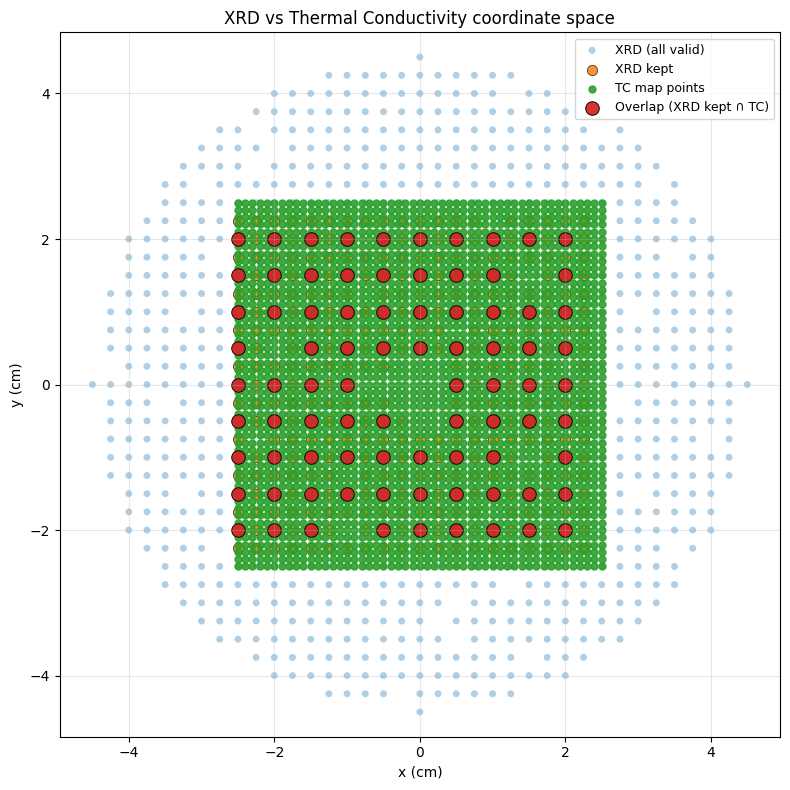

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def plot_coordinate_space(
    valid_df=None,
    valid_df_masked=None,
    df_tc_clean=None,
    mask_center=None,
    title="Coordinate space (XRD + Tc)"
):
    if valid_df is None and valid_df_masked is None:
        raise ValueError("Provide at least one of valid_df or valid_df_masked.")
    if df_tc_clean is None:
        raise ValueError("Provide df_tc_clean (TC map coordinates).")

    if valid_df is not None:
        for c in ("x", "y"):
            if c not in valid_df.columns:
                raise KeyError(f"valid_df missing column '{c}'")
    if valid_df_masked is not None:
        for c in ("x", "y"):
            if c not in valid_df_masked.columns:
                raise KeyError(f"valid_df_masked missing column '{c}'")
    for c in ("x", "y"):
        if c not in df_tc_clean.columns:
            raise KeyError(f"df_tc_clean missing column '{c}'")

    plt.figure(figsize=(8, 8))

    if valid_df is not None:
        plt.scatter(valid_df["x"], valid_df["y"], s=25, alpha=0.35, label="XRD (all valid)", edgecolor="none")

    if (valid_df is not None) and (mask_center is not None):
        mask_center = np.asarray(mask_center, dtype=bool)
        if mask_center.shape[0] != len(valid_df):
            raise ValueError("mask_center must have same length as valid_df.")
        plt.scatter(
            valid_df.loc[mask_center, "x"], valid_df.loc[mask_center, "y"],
            s=55, alpha=0.85, label="XRD masked-out", edgecolor="k", linewidth=0.5
        )

    if valid_df_masked is not None:
        plt.scatter(
            valid_df_masked["x"], valid_df_masked["y"],
            s=55, alpha=0.85, label="XRD kept", edgecolor="k", linewidth=0.5
        )

    plt.scatter(df_tc_clean["x"], df_tc_clean["y"], s=25, alpha=0.9, label="TC map points")

    if valid_df_masked is not None:
        L = valid_df_masked[["x", "y"]].copy()
        R = df_tc_clean[["x", "y"]].copy()
        nd = 4
        L["_xr"] = L["x"].round(nd); L["_yr"] = L["y"].round(nd)
        R["_xr"] = R["x"].round(nd); R["_yr"] = R["y"].round(nd)
        overlap = pd.merge(L, R, on=["_xr", "_yr"], how="inner")
        if len(overlap) > 0:
            plt.scatter(overlap["_xr"], overlap["_yr"], s=95, alpha=0.95,
                        label="Overlap (XRD kept ∩ TC)", edgecolor="k", linewidth=0.7)

    plt.xlabel("x (cm)")
    plt.ylabel("y (cm)")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.axis("equal")
    plt.legend(loc="best", fontsize=9)
    plt.tight_layout()
    plt.show()

plot_coordinate_space(
    valid_df=valid_df,
    valid_df_masked=valid_df_masked,
    df_tc_clean=df_tc_clean,
    title="XRD vs Thermal Conductivity coordinate space"
)

## 5. Tokenization and model-ready tensors

In [ ]:
X_intensity_raw = X
two_theta_used  = theta_feat
y_raw           = y

X_intensity_raw = np.asarray(X_intensity_raw, dtype=np.float32)
two_theta_used  = np.asarray(two_theta_used, dtype=np.float32)
y_raw           = np.asarray(y_raw, dtype=np.float32)

assert X_intensity_raw.ndim == 2
assert two_theta_used.ndim == 1
assert y_raw.ndim == 1
assert X_intensity_raw.shape[0] == y_raw.shape[0]
assert X_intensity_raw.shape[1] == two_theta_used.shape[0]

N, Nbins = X_intensity_raw.shape
print("N samples:", N, "| N bins:", Nbins)
print("2θ range:", float(two_theta_used.min()), "to", float(two_theta_used.max()))

def to_log_input(X, q=95, eps_scale=1e-6):
    X = np.asarray(X, dtype=np.float32)
    row_min = X.min(axis=1, keepdims=True)
    Xs = X - np.minimum(row_min, 0.0)

    s = np.percentile(Xs, q, axis=1, keepdims=True).astype(np.float32)
    s[s == 0] = 1.0
    Xn = Xs / s

    eps = (eps_scale * np.ones_like(s)).astype(np.float32)
    return np.log1p(Xn + eps).astype(np.float32)

I_log = to_log_input(X_intensity_raw, q=95, eps_scale=1e-6)

theta = two_theta_used.copy()
theta = (theta - theta.mean()) / (theta.std() + 1e-8)
theta_feat_norm = np.broadcast_to(theta[None, :], I_log.shape)

X_model = np.stack([I_log, theta_feat_norm], axis=-1).astype(np.float32)
print("X_model:", X_model.shape)

N samples: 355 | N bins: 120
2θ range: 2.2200469970703125 to 8.919281959533691
X_model: (355, 120, 2)


## 6. Target normalization

In [ ]:
y_mu = float(y_raw.mean())
y_sigma = float(y_raw.std() + 1e-8)

def to_train_units(y_phys):
    return (y_phys - y_mu) / y_sigma

def to_phys_units(y_train):
    return y_train * y_sigma + y_mu

y_train_units = to_train_units(y_raw).astype(np.float32)

print("Target:", "mean =", y_mu, "std =", y_sigma)
print("y_raw range:", float(y_raw.min()), "to", float(y_raw.max()))

Target: mean = 0.7743365168571472 std = 0.1719575822353363
y_raw range: 0.0 to 1.4629312753677368


## 7. Transformer + Attention Pooling model

In [ ]:
class SelfAttention(nn.Module):
    def __init__(self, dim, heads=4):
        super().__init__()
        assert dim % heads == 0
        self.dim = dim
        self.heads = heads
        self.head_dim = dim // heads
        self.to_qkv = nn.Linear(dim, dim * 3)
        self.to_out = nn.Linear(dim, dim)
        self.scale = self.head_dim ** -0.5

    def forward(self, x):  # (B,N,D)
        b, n, d = x.shape
        qkv = self.to_qkv(x).chunk(3, dim=-1)
        q, k, v = [t.view(b, n, self.heads, self.head_dim).transpose(1, 2) for t in qkv]
        dots = torch.matmul(q, k.transpose(-1, -2)) * self.scale
        attn = dots.softmax(dim=-1)
        out = torch.matmul(attn, v)
        out = out.transpose(1, 2).reshape(b, n, d)
        return self.to_out(out)

class AttentionPool(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.query = nn.Parameter(torch.randn(dim))
        self.log_tau = nn.Parameter(torch.tensor(0.0))
        self.last_alpha = None
        self.last_tau = None

    def forward(self, tokens):  # (B,N,D)
        scores = torch.einsum("bnd,d->bn", tokens, self.query)
        tau = F.softplus(self.log_tau) + 1e-4
        alpha = F.softmax(scores / tau, dim=-1)
        ctx = torch.einsum("bn,bnd->bd", alpha, tokens)
        self.last_alpha = alpha
        self.last_tau = tau
        return ctx

class TransformerExplainableRegressor(nn.Module):
    def __init__(self, n_bins, in_feats=2, hidden_dim=64, heads=4, depth=2):
        super().__init__()
        self.n_bins = n_bins
        self.embed = nn.Linear(in_feats, hidden_dim)
        self.pos = nn.Parameter(torch.randn(1, n_bins, hidden_dim) * 0.02)

        self.blocks = nn.ModuleList([])
        for _ in range(depth):
            attn = SelfAttention(hidden_dim, heads=heads)
            norm1 = nn.LayerNorm(hidden_dim)
            ff = nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim * 4),
                nn.GELU(),
                nn.Linear(hidden_dim * 4, hidden_dim),
            )
            norm2 = nn.LayerNorm(hidden_dim)
            self.blocks.append(nn.ModuleList([attn, norm1, ff, norm2]))

        self.pool = AttentionPool(hidden_dim)
        self.out = nn.Linear(hidden_dim, 1)

        self.pool_attention = None
        self.tau = None

    def forward(self, x):
        B, N, C = x.shape
        assert N == self.n_bins, f"Expected N={self.n_bins}, got N={N}"

        h = self.embed(x) + self.pos[:, :N, :]

        for attn, norm1, ff, norm2 in self.blocks:
            h = norm1(h + attn(h))
            h = norm2(h + ff(h))

        ctx = self.pool(h)
        y = self.out(ctx)

        self.pool_attention = self.pool.last_alpha
        self.tau = self.pool.last_tau
        return y

## 8. Regularizers

In [ ]:
def smoothness_loss(alpha_bn, lambda_smooth=0.02):
    return lambda_smooth * torch.abs(alpha_bn[:, 1:] - alpha_bn[:, :-1]).mean()

## 9. Train/Val split and DataLoaders

In [ ]:
X_train, X_val, y_train, y_val, ytrain_phys, yval_phys = train_test_split(
    X_model, y_train_units, y_raw, test_size=0.2, random_state=42
)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_val_t   = torch.tensor(X_val,   dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
y_val_t   = torch.tensor(y_val,   dtype=torch.float32).unsqueeze(1)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val_t,   y_val_t),   batch_size=32, shuffle=False)

print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape, y_val.shape)

Train: (284, 120, 2) (284,)
Val:   (71, 120, 2) (71,)


## 10. Training

In [ ]:
n_bins = X_model.shape[1]

model = TransformerExplainableRegressor(
    n_bins=n_bins,
    in_feats=2,
    hidden_dim=64,
    heads=4,
    depth=2
).to(DEVICE)

criterion = nn.SmoothL1Loss(beta=0.5)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-2)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=300)

lambda_smooth = 0.08
lambda_tau    = 1e-3
tau0          = 1.0

history = {"train": [], "val": [], "pred_train": [], "pred_val": [], "tau": []}

n_epochs = 500
for epoch in range(n_epochs):
    model.train()
    tr_total, tr_pred = 0.0, 0.0

    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)

        optimizer.zero_grad()
        y_pred = model(xb)

        pred_loss = criterion(y_pred, yb)
        alpha = model.pool_attention
        sm = smoothness_loss(alpha, lambda_smooth=lambda_smooth)

        tau = model.tau
        tau_prior = lambda_tau * ((torch.log(tau) - np.log(tau0))**2).mean()

        loss = pred_loss + sm + tau_prior
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        tr_total += float(loss.item())
        tr_pred  += float(pred_loss.item())

    tr_total /= len(train_loader)
    tr_pred  /= len(train_loader)

    model.eval()
    va_total, va_pred = 0.0, 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            y_pred = model(xb)

            pred_loss = criterion(y_pred, yb)
            alpha = model.pool_attention
            sm = smoothness_loss(alpha, lambda_smooth=lambda_smooth)
            tau = model.tau
            tau_prior = lambda_tau * ((torch.log(tau) - np.log(tau0))**2).mean()

            va_total += float((pred_loss + sm + tau_prior).item())
            va_pred  += float(pred_loss.item())

    va_total /= len(val_loader)
    va_pred  /= len(val_loader)

    scheduler.step()

    history["train"].append(tr_total)
    history["val"].append(va_total)
    history["pred_train"].append(tr_pred)
    history["pred_val"].append(va_pred)
    history["tau"].append(float(model.tau.detach().cpu().item()))

    if epoch % 25 == 0 or epoch == n_epochs - 1:
        print(f"Epoch {epoch:03d} | tr {tr_total:.4f} va {va_total:.4f} | pred tr {tr_pred:.4f} va {va_pred:.4f} | tau {history['tau'][-1]:.4f}")

Epoch 000 | tr 0.5839 va 0.4451 | pred tr 0.5834 va 0.4446 | tau 0.6943
Epoch 025 | tr 0.4427 va 0.3258 | pred tr 0.4414 va 0.3244 | tau 0.6964
Epoch 050 | tr 0.4349 va 0.2754 | pred tr 0.4335 va 0.2739 | tau 0.7025
Epoch 075 | tr 0.4467 va 0.3051 | pred tr 0.4453 va 0.3037 | tau 0.7082
Epoch 100 | tr 0.4304 va 0.3013 | pred tr 0.4289 va 0.2998 | tau 0.7141
Epoch 125 | tr 0.4329 va 0.2690 | pred tr 0.4315 va 0.2675 | tau 0.7198
Epoch 150 | tr 0.4363 va 0.3241 | pred tr 0.4348 va 0.3226 | tau 0.7235
Epoch 175 | tr 0.4154 va 0.2654 | pred tr 0.4139 va 0.2640 | tau 0.7264
Epoch 200 | tr 0.4043 va 0.3412 | pred tr 0.4029 va 0.3397 | tau 0.7280
Epoch 225 | tr 0.3494 va 0.2749 | pred tr 0.3479 va 0.2735 | tau 0.7287
Epoch 250 | tr 0.3402 va 0.2812 | pred tr 0.3388 va 0.2798 | tau 0.7287
Epoch 275 | tr 0.3399 va 0.2854 | pred tr 0.3385 va 0.2840 | tau 0.7288
Epoch 300 | tr 0.3391 va 0.2863 | pred tr 0.3377 va 0.2849 | tau 0.7288
Epoch 325 | tr 0.3388 va 0.2827 | pred tr 0.3374 va 0.2813 | tau

## 11. Training diagnostics plots

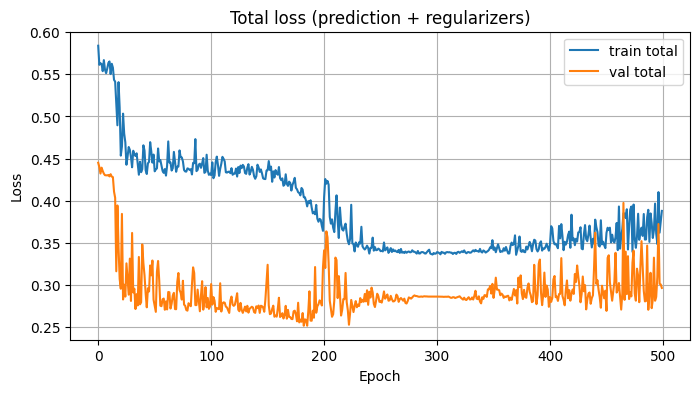

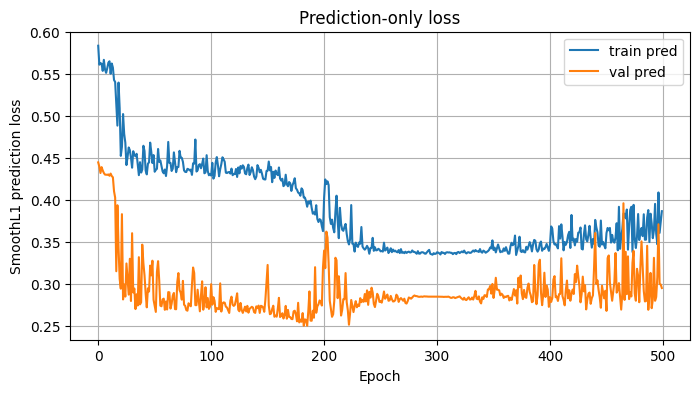

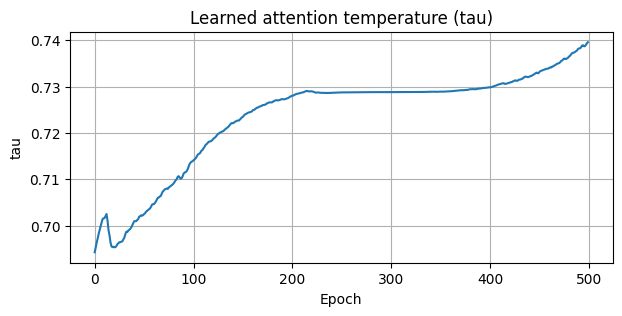

In [ ]:
plt.figure(figsize=(8,4))
plt.plot(history["train"], label="train total")
plt.plot(history["val"], label="val total")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("Total loss (prediction + regularizers)")
plt.grid(True); plt.legend(); plt.show()

plt.figure(figsize=(8,4))
plt.plot(history["pred_train"], label="train pred")
plt.plot(history["pred_val"], label="val pred")
plt.xlabel("Epoch"); plt.ylabel("SmoothL1 prediction loss")
plt.title("Prediction-only loss")
plt.grid(True); plt.legend(); plt.show()

plt.figure(figsize=(7,3))
plt.plot(history["tau"])
plt.xlabel("Epoch"); plt.ylabel("tau")
plt.title("Learned attention temperature (tau)")
plt.grid(True); plt.show()

## 12. Evaluation

Val RMSE (phys): 0.11821644753217697
Val MAE  (phys): 0.09072625637054443
Baseline RMSE (mean predictor): 0.1443149745464325


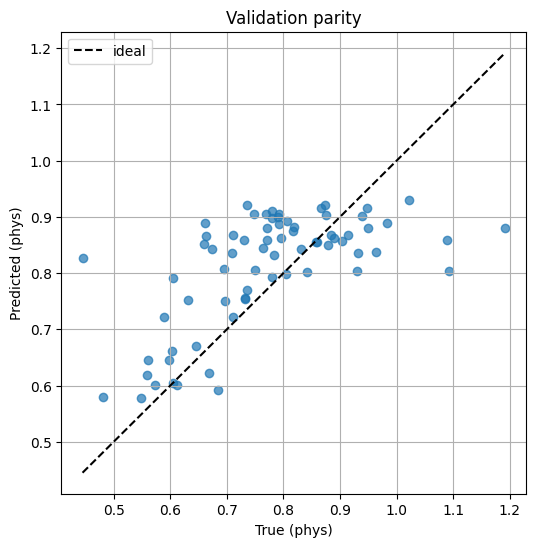

In [ ]:
def predict_np(model, X_np, batch_size=128):
    model.eval()
    dev = next(model.parameters()).device
    out = []
    with torch.no_grad():
        for i in range(0, len(X_np), batch_size):
            xb = torch.tensor(X_np[i:i+batch_size], dtype=torch.float32, device=dev)
            yb = model(xb).detach().cpu().numpy()
            out.append(yb)
    return np.vstack(out).reshape(-1)

y_pred_val_train = predict_np(model, X_val)
y_pred_val_phys  = to_phys_units(y_pred_val_train)

rmse = float(np.sqrt(np.mean((yval_phys - y_pred_val_phys)**2)))
mae  = float(np.mean(np.abs(yval_phys - y_pred_val_phys)))
print("Val RMSE (phys):", rmse)
print("Val MAE  (phys):", mae)

y_mean = float(np.mean(ytrain_phys))
rmse_mean = float(np.sqrt(np.mean((yval_phys - y_mean)**2)))
print("Baseline RMSE (mean predictor):", rmse_mean)

plt.figure(figsize=(6,6))
plt.scatter(yval_phys, y_pred_val_phys, alpha=0.7)
mn, mx = float(np.min(yval_phys)), float(np.max(yval_phys))
plt.plot([mn, mx], [mn, mx], "k--", label="ideal")
plt.xlabel("True (phys)")
plt.ylabel("Predicted (phys)")
plt.title("Validation parity")
plt.grid(True)
plt.legend()
plt.show()

## 13. Attention extraction and plotting

[idx=0] tau=0.7396 | entropy=0.4536 | top10_mass=1.0000


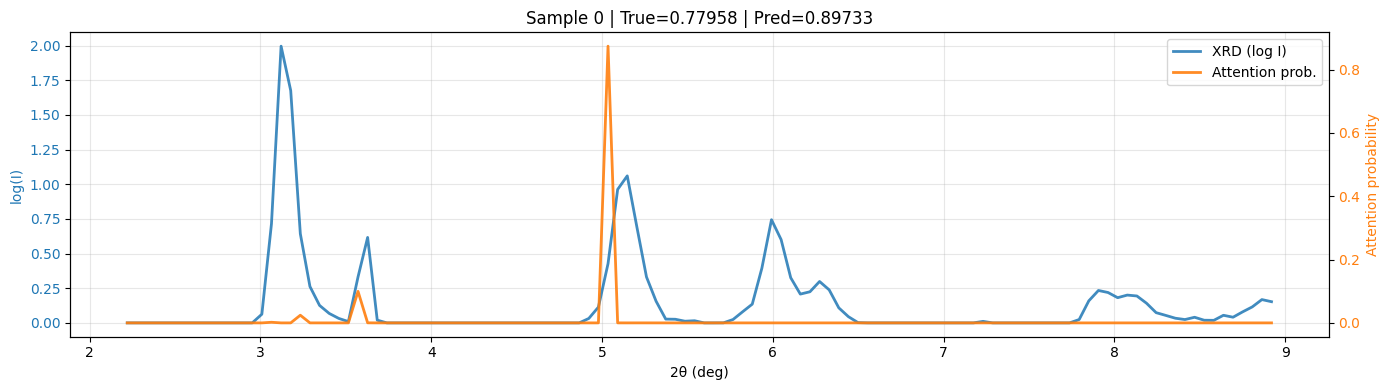

[idx=1] tau=0.7396 | entropy=1.2245 | top10_mass=1.0000


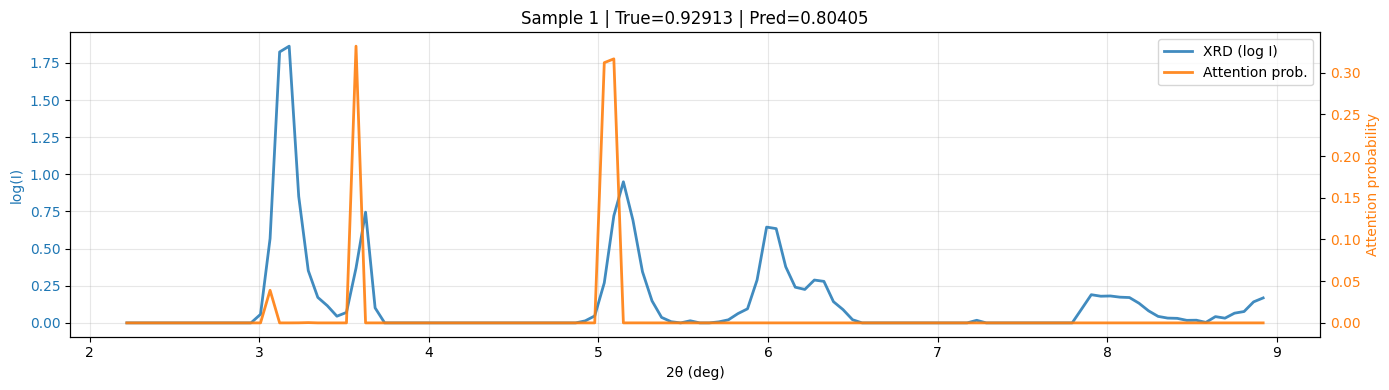

[idx=2] tau=0.7396 | entropy=0.8444 | top10_mass=1.0000


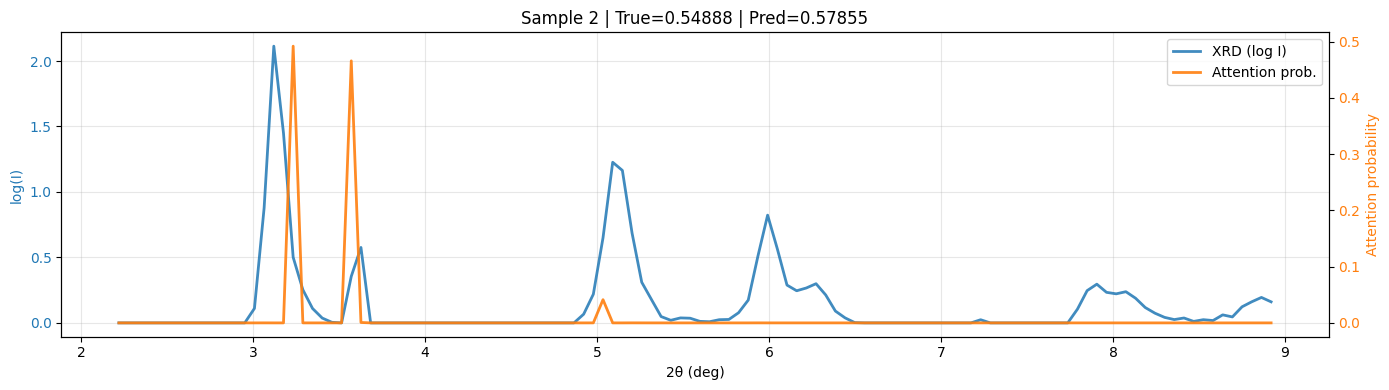

In [ ]:
axis = np.asarray(two_theta_used, dtype=np.float32)

def plot_attention_sample(idx):
    spec = X_val[idx].astype(np.float32)  # (Nbins,2)

    model.eval()
    with torch.no_grad():
        xb = torch.tensor(spec, dtype=torch.float32).unsqueeze(0).to(DEVICE)
        pred_train = model(xb).item()
        alpha = model.pool_attention[0].detach().cpu().numpy()

    pred_phys = float(to_phys_units(np.array([pred_train]))[0])
    true_phys = float(yval_phys[idx])

    tau = float(model.tau.detach().cpu().item())
    entropy = float(-(alpha * np.log(alpha + 1e-12)).sum())
    top10_mass = float(np.sort(alpha)[-10:].sum())
    print(f"[idx={idx}] tau={tau:.4f} | entropy={entropy:.4f} | top10_mass={top10_mass:.4f}")

    fig, ax1 = plt.subplots(figsize=(14,4))
    ax1.plot(axis, spec[:, 0], color="tab:blue", linewidth=2, alpha=0.85, label="XRD (log I)")
    ax1.set_xlabel("2θ (deg)")
    ax1.set_ylabel("log(I)", color="tab:blue")
    ax1.tick_params(axis="y", labelcolor="tab:blue")
    ax1.grid(True, alpha=0.3)

    ax2 = ax1.twinx()
    ax2.plot(axis, alpha, color="tab:orange", linewidth=2, alpha=0.9, label="Attention prob.")
    ax2.set_ylabel("Attention probability", color="tab:orange")
    ax2.tick_params(axis="y", labelcolor="tab:orange")

    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax1.legend(h1 + h2, l1 + l2, loc="upper right")

    ax1.set_title(f"Sample {idx} | True={true_phys:.5f} | Pred={pred_phys:.5f}")
    plt.tight_layout()
    plt.show()

for idx in [0, 1, 2]:
    plot_attention_sample(idx)

## 14. Global attention summaries

alphas: (71, 120)


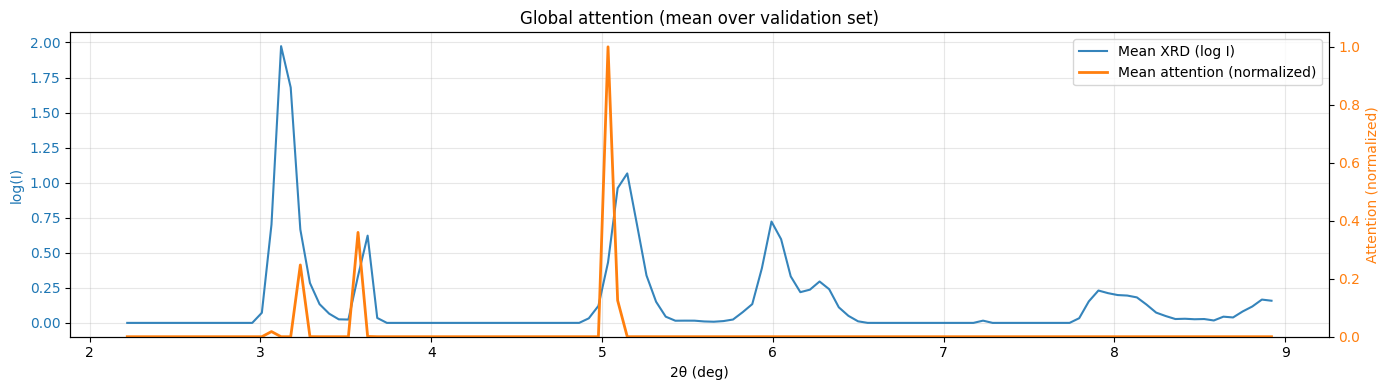

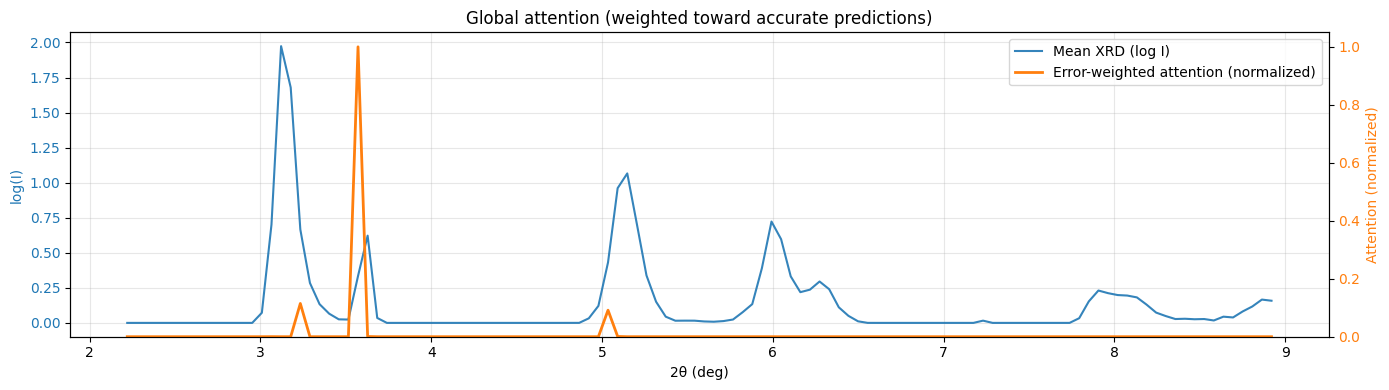

In [ ]:
def collect_attention(model, X_np, device, max_items=None, batch_size=128):
    model.eval()
    n = len(X_np) if max_items is None else min(len(X_np), max_items)
    alphas = []

    with torch.no_grad():
        for i in range(0, n, batch_size):
            xb = torch.tensor(X_np[i:i+batch_size], dtype=torch.float32, device=device)
            _ = model(xb)
            alpha = model.pool_attention.detach().cpu().numpy()
            alphas.append(alpha)

    return np.vstack(alphas).astype(np.float32)

alphas = collect_attention(model, X_val, DEVICE, max_items=None)
print("alphas:", alphas.shape)

alpha_mean = alphas.mean(axis=0)
alpha_mean_norm = alpha_mean / (alpha_mean.max() + 1e-12)

spec_mean = X_val[:, :, 0].mean(axis=0)

fig, ax1 = plt.subplots(figsize=(14,4))
ax1.plot(axis, spec_mean, color="tab:blue", label="Mean XRD (log I)", alpha=0.9)
ax1.set_xlabel("2θ (deg)")
ax1.set_ylabel("log(I)", color="tab:blue")
ax1.tick_params(axis='y', labelcolor="tab:blue")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(axis, alpha_mean_norm, color="tab:orange", label="Mean attention (normalized)", linewidth=2)
ax2.set_ylabel("Attention (normalized)", color="tab:orange")
ax2.tick_params(axis='y', labelcolor="tab:orange")
ax2.set_ylim(0, 1.05)

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1+h2, l1+l2, loc="upper right")
ax1.set_title("Global attention (mean over validation set)")
plt.tight_layout()
plt.show()

pred_phys = to_phys_units(predict_np(model, X_val))
errs = np.abs(pred_phys - yval_phys)

w = 1.0 / (errs + 1e-6)
w = w / w.sum()

alpha_wmean = (alphas * w[:, None]).sum(axis=0)
alpha_wmean_norm = alpha_wmean / (alpha_wmean.max() + 1e-12)

fig, ax1 = plt.subplots(figsize=(14,4))
ax1.plot(axis, spec_mean, color="tab:blue", label="Mean XRD (log I)", alpha=0.9)
ax1.set_xlabel("2θ (deg)")
ax1.set_ylabel("log(I)", color="tab:blue")
ax1.tick_params(axis='y', labelcolor="tab:blue")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(axis, alpha_wmean_norm, color="tab:orange", label="Error-weighted attention (normalized)", linewidth=2)
ax2.set_ylabel("Attention (normalized)", color="tab:orange")
ax2.tick_params(axis='y', labelcolor="tab:orange")
ax2.set_ylim(0, 1.05)

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1+h2, l1+l2, loc="upper right")
ax1.set_title("Global attention (weighted toward accurate predictions)")
plt.tight_layout()
plt.show()

Some ideas to explore with this notebook:
1) Preprocessing sensitivity (XRD-specific, but useful for any spectra)

- Try controlled variants and see what changes:

- log(I) vs raw I vs normalized I

- smoothing / background subtraction on/off

- interpolation to different bin counts (L)
Then check whether attention shifts to artifacts.

2) Spatial mapping task 

    If your dataset has (x, y):

- Plot predicted target across the sample map

- Plot attention-derived scalar summaries across (x, y), e.g.:

- attention mass inside a chosen spectral window

- attention entropy / concentration

- learned tau (if stored per-run)



3) Physics-guided hypothesis generation (use attention to propose peaks/regions)

    Identify top attention regions and map them to candidate peaks / bands (manual or with a simple peak finder).

    Ask: do those regions correlate with known phases, strain signatures, or compositional trends?

